In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from config import PATHS, PARAMS

matplotlib.rcParams["font.family"] = "Arial"
plt.style.use("seaborn-v0_8-talk")

### Gaussian Process : Logic

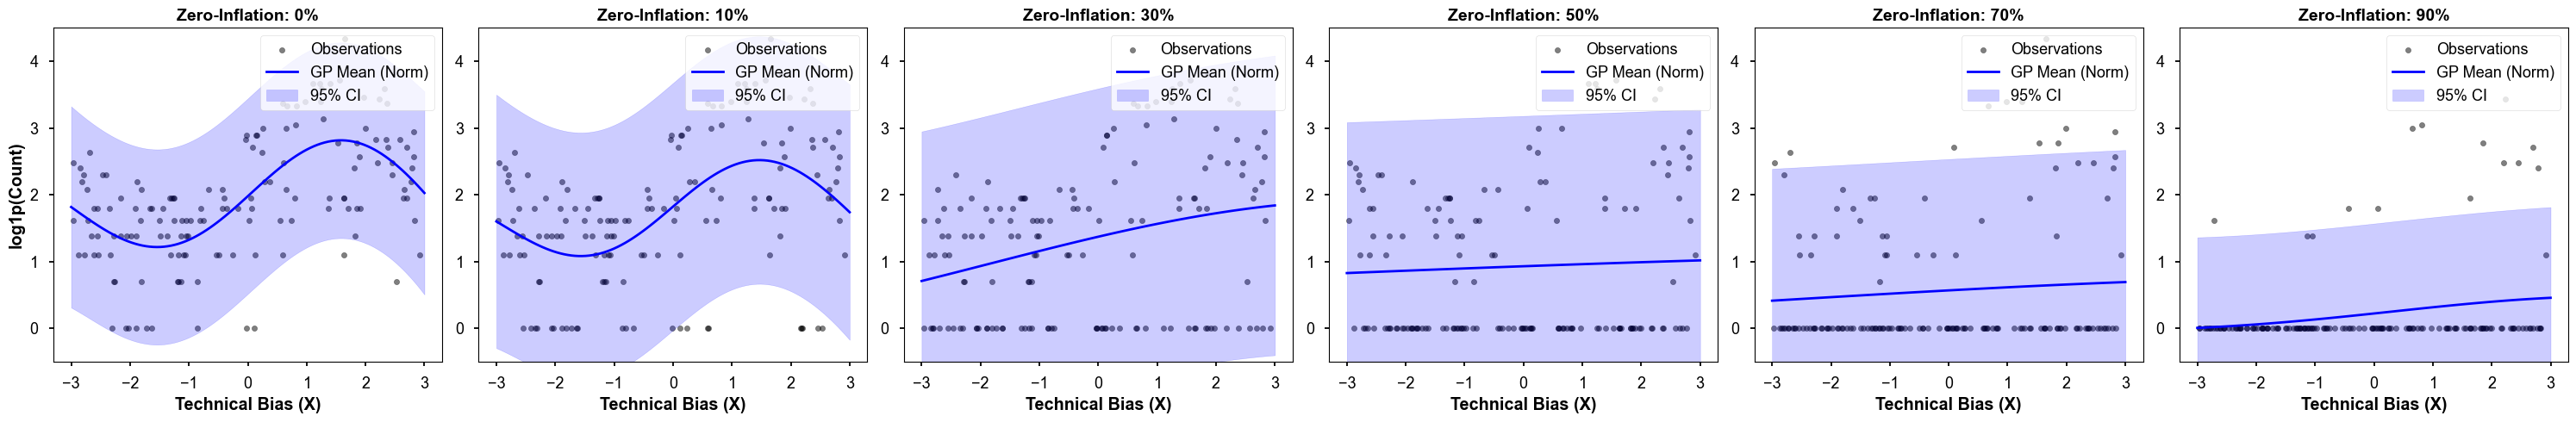

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

def simulate_zinb_gp_collapse(zero_ratios=[0.0, 0.5, 0.9]):
    np.random.seed(42)
    N = 150  
    X = np.random.uniform(-3, 3, N).reshape(-1, 1)
    true_mu = np.exp(np.sin(X[:, 0]) + 2)
    n_dispersion = 2.0 
    p = n_dispersion / (n_dispersion + true_mu)
    counts_nb = np.random.negative_binomial(n_dispersion, p)

    fig, axes = plt.subplots(1, len(zero_ratios), figsize=(5 * len(zero_ratios), 5))

    for i, z_ratio in enumerate(zero_ratios):
        counts_zinb = counts_nb.copy()
        num_zeros = int(N * z_ratio)
        if num_zeros > 0:
            zero_indices = np.random.choice(N, size=num_zeros, replace=False)
            counts_zinb[zero_indices] = 0

        Y = np.log1p(counts_zinb)

        kernel = 1.0 * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) \
                 + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-3, 1e1))
        
        gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5)
        gp.fit(X, Y)

        X_plot = np.linspace(-3, 3, 100).reshape(-1, 1)
        mu_pred, std_pred = gp.predict(X_plot, return_std=True)

        ax = axes[i]
        ax.scatter(X, Y, color='black', alpha=0.5, s=20, label='Observations')
        ax.plot(X_plot, mu_pred, color='blue', linewidth=2, label='GP Mean (Norm)')
        ax.fill_between(X_plot[:, 0], 
                        mu_pred - 1.96 * std_pred, 
                        mu_pred + 1.96 * std_pred, 
                        color='blue', alpha=0.2, label='95% CI')
        
        ax.set_title(f"Zero-Inflation: {int(z_ratio*100)}%", fontweight='bold', fontsize=14)
        ax.set_xlabel("Technical Bias (X)", fontweight='bold')
        if i == 0:
            ax.set_ylabel("log1p(Count)", fontweight='bold')
        
        ax.set_ylim(-0.5, 4.5)
        ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

# 실행
simulate_zinb_gp_collapse([0.0, 0.1, 0.3, 0.5, 0.7, 0.9])

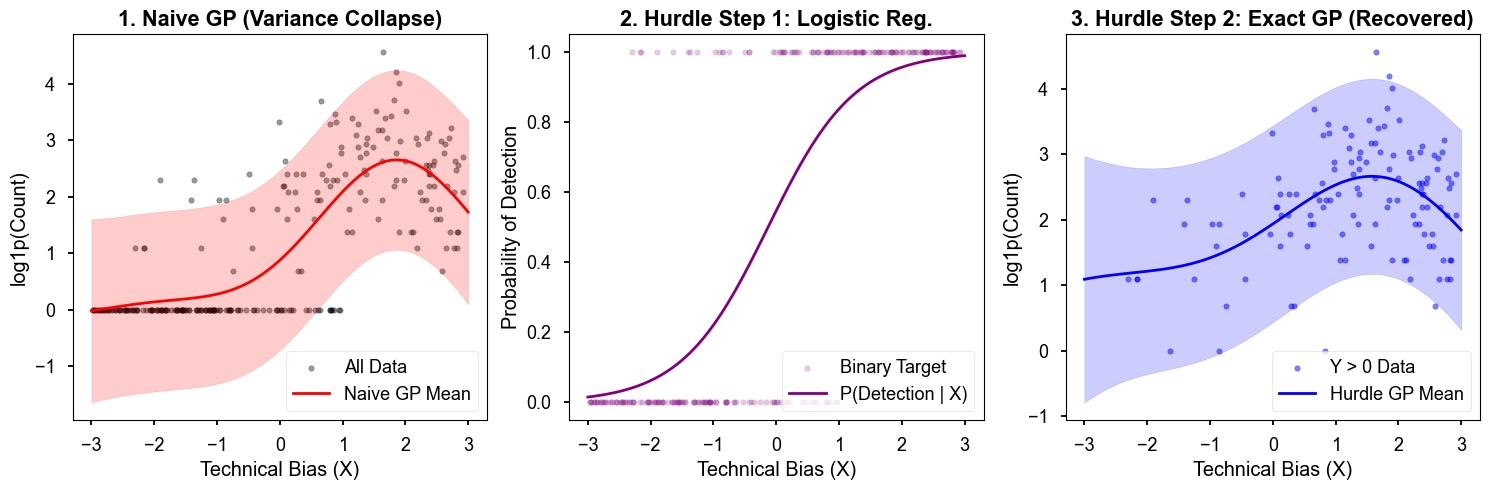

In [5]:
from sklearn.linear_model import LogisticRegression

def simulate_hurdle_gp():
    np.random.seed(42)
    N = 250
    X = np.random.uniform(-3, 3, N).reshape(-1, 1)
    true_mu = np.exp(np.sin(X[:, 0]) + 2)
    n_dispersion = 2.0
    p = n_dispersion / (n_dispersion + true_mu)
    counts_nb = np.random.negative_binomial(n_dispersion, p)

    prob_detection = 1 / (1 + np.exp(-1.5 * (X[:, 0] + 0.2)))
    detected = np.random.binomial(1, prob_detection)
    counts_zinb = counts_nb * detected
    Y = np.log1p(counts_zinb)
    
    kernel_naive = 1.0 * RBF(length_scale=1.0) + WhiteKernel(noise_level=1.0)
    gp_naive = GaussianProcessRegressor(kernel=kernel_naive, n_restarts_optimizer=5)
    gp_naive.fit(X, Y)
    
    # Step 1: Logistic Regression for Detection (0 vs >0)
    clf = LogisticRegression()
    clf.fit(X, detected)
    
    # Step 2: Exact GP strictly for Y > 0
    mask_pos = detected == 1
    X_pos, Y_pos = X[mask_pos], Y[mask_pos]
    kernel_hurdle = 1.0 * RBF(length_scale=1.0) + WhiteKernel(noise_level=1.0)
    gp_hurdle = GaussianProcessRegressor(kernel=kernel_hurdle, n_restarts_optimizer=5)
    gp_hurdle.fit(X_pos, Y_pos)
    
    X_plot = np.linspace(-3, 3, 100).reshape(-1, 1)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Panel 1: Naive GP Failure
    mu_naive, std_naive = gp_naive.predict(X_plot, return_std=True)
    axes[0].scatter(X, Y, color='black', alpha=0.4, s=15, label='All Data')
    axes[0].plot(X_plot, mu_naive, color='red', lw=2, label='Naive GP Mean')
    axes[0].fill_between(X_plot[:, 0], mu_naive - 1.96*std_naive, mu_naive + 1.96*std_naive, color='red', alpha=0.2)
    axes[0].set_title("1. Naive GP (Variance Collapse)", fontweight='bold')
    axes[0].set_xlabel("Technical Bias (X)")
    axes[0].set_ylabel("log1p(Count)")
    
    # Panel 2: Hurdle Step 1 (Detection Prob)
    prob_pred = clf.predict_proba(X_plot)[:, 1]
    axes[1].scatter(X, detected, color='purple', alpha=0.2, s=15, label='Binary Target')
    axes[1].plot(X_plot, prob_pred, color='purple', lw=2, label='P(Detection | X)')
    axes[1].set_title("2. Hurdle Step 1: Logistic Reg.", fontweight='bold')
    axes[1].set_xlabel("Technical Bias (X)")
    axes[1].set_ylabel("Probability of Detection")
    
    # Panel 3: Hurdle Step 2 (Normative GP)
    mu_hurdle, std_hurdle = gp_hurdle.predict(X_plot, return_std=True)
    axes[2].scatter(X_pos, Y_pos, color='blue', alpha=0.5, s=15, label='Y > 0 Data')
    axes[2].plot(X_plot, mu_hurdle, color='blue', lw=2, label='Hurdle GP Mean')
    axes[2].fill_between(X_plot[:, 0], mu_hurdle - 1.96*std_hurdle, mu_hurdle + 1.96*std_hurdle, color='blue', alpha=0.2)
    axes[2].set_title("3. Hurdle Step 2: Exact GP (Recovered)", fontweight='bold')
    axes[2].set_xlabel("Technical Bias (X)")
    axes[2].set_ylabel("log1p(Count)")
    
    for ax in axes:
        ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

simulate_hurdle_gp()

Ratio   | P-state   | Z-state  | P-quant   | Z-quant 
-----------------------------------------------------
  20%     |   0.7192  |     0.00 |   0.0069  |     2.46
  50%     |   0.4753  |     0.06 |   0.0101  |     2.32
  90%     |   0.1266  |     1.14 |   0.0058  |     2.52
  99%     |   0.0114  |     2.28 |   1.0000  |     0.00


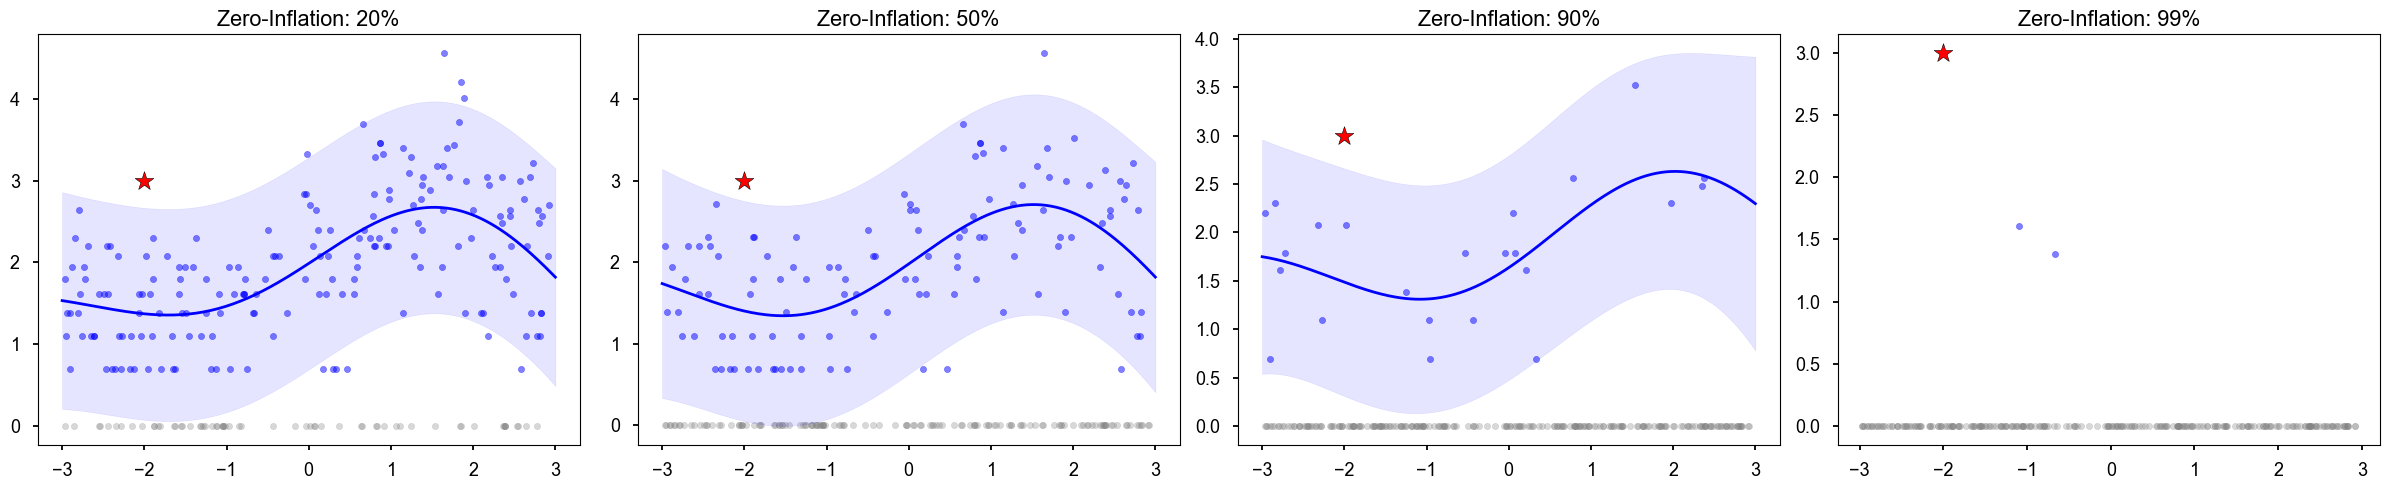

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.linear_model import LogisticRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
import warnings

warnings.filterwarnings('ignore')

def simulate_hurdle_with_pvalues(zero_ratios=[0.2, 0.5, 0.9]):
    np.random.seed(42)
    N = 250
    X = np.random.uniform(-3, 3, N).reshape(-1, 1)
    
    # Base biological signal
    true_mu = np.exp(np.sin(X[:, 0]) + 2)
    n_dispersion = 2.0
    p_nb = n_dispersion / (n_dispersion + true_mu)
    counts_nb = np.random.negative_binomial(n_dispersion, p_nb)

    # Test case: New patient (X=-2.0, Y=4.0)
    X_new = np.array([[-2.0]])
    Y_new = 3.0

    fig, axes = plt.subplots(1, len(zero_ratios), figsize=(6 * len(zero_ratios), 5))
    X_plot = np.linspace(-3, 3, 200).reshape(-1, 1)

    # 헤더 출력 (P-value 항목 추가)
    header = f"{'Ratio':<7} | {'P-state':<9} | {'Z-state':<8} | {'P-quant':<9} | {'Z-quant':<8}"
    print(header)
    print("-" * len(header))

    for i, z_ratio in enumerate(zero_ratios):
        counts_zinb = counts_nb.copy()
        num_zeros = int(N * z_ratio)
        zero_indices = np.random.choice(N, size=num_zeros, replace=False)
        counts_zinb[zero_indices] = 0
        
        is_detected = (counts_zinb > 0).astype(int)
        Y = np.log1p(counts_zinb)
        ax = axes[i]

        # Step 1: Logistic Regression (State Anomaly)
        clf = LogisticRegression()
        clf.fit(X, is_detected)
        p_detect_new = clf.predict_proba(X_new)[0, 1]
        
        # P-state: 정상군에서 이 조건에 발현될 확률 자체가 P-value
        p_val_state = p_detect_new 
        z_state = norm.ppf(1 - p_val_state) if p_val_state < 0.5 else 0.0

        # Step 2: Exact GP (Quantity Anomaly)
        X_pos, Y_pos = X[is_detected == 1], Y[is_detected == 1]
        
        if len(X_pos) > 5:
            kernel = 1.0 * RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1)
            gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5)
            gp.fit(X_pos, Y_pos)
            mu_q, std_q = gp.predict(X_new, return_std=True)
            z_quant = (Y_new - mu_q[0]) / std_q[0]
            # P-quant: 단측 검정 (상위 발현일 확률)
            p_val_quant = 1 - norm.cdf(z_quant)
            
            mu_plot, std_plot = gp.predict(X_plot, return_std=True)
        else:
            p_val_quant, z_quant = 1.0, 0.0
            mu_plot = None

        # 시각화 부분 생략 가능 (코드 압축)
        ax.scatter(X[is_detected == 0], Y[is_detected == 0], color='gray', alpha=0.3, s=20)
        ax.scatter(X_pos, Y_pos, color='blue', alpha=0.5, s=20)
        if mu_plot is not None:
            ax.plot(X_plot, mu_plot, color='blue', lw=2)
            ax.fill_between(X_plot[:, 0], mu_plot - 1.96*std_plot, mu_plot + 1.96*std_plot, color='blue', alpha=0.1)
        ax.scatter(X_new, Y_new, color='red', marker='*', s=200, edgecolor='black', zorder=5)
        ax.set_title(f"Zero-Inflation: {int(z_ratio*100)}%")

        # 결과 출력
        print(f"{int(z_ratio*100):>4}%     | {p_val_state:>8.4f}  | {z_state:>8.2f} | {p_val_quant:>8.4f}  | {z_quant:>8.2f}")

    plt.tight_layout()
    plt.show()

simulate_hurdle_with_pvalues([0.2, 0.5, 0.9, 0.99])

### Toy Model Test : HVG (n=20)

In [ ]:
adata = sc.read_h5ad(PATHS["merged_qc"])
adata = adata[adata.obs["QC_Passed"] == True]
adata = adata[adata.obs["Phenotype_Processed"] == "Healthy Control"]

In [16]:
n_genes = 1000
sc.pp.filter_genes(adata, min_cells=1)
sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=n_genes)
bias_columns = ['log(Total Reads)',
                'Spliced Reads (%)',
                'gDNA Contamination (Intron/Exon)',
                'rRNA Fraction',
                "RNA Degradation (3' Bias)",
                'Platelet Score',
                'GC Bias',
                'Gene Length Bias',
                'NG80',
                '(NP80/NG80)']
bias_df = adata.obs[bias_columns]

In [17]:
from sklearn.preprocessing import StandardScaler

X_Raw = bias_df.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_Raw)
hvg_names = adata.var_names[adata.var.highly_variable]
raw_layer = adata[:, hvg_names].layers['Raw']
sparsity = (raw_layer.toarray() == 0).mean(axis=0) if hasattr(raw_layer, "toarray") else (raw_layer == 0).mean(axis=0)

s_df = pd.DataFrame({'gene': hvg_names, 'sparsity': sparsity})
s_df = s_df[s_df['sparsity'] != 1.]

test_genes = (list(s_df[s_df['sparsity'] < 0.1].sample(2, random_state=42)['gene']) + 
                list(s_df[(s_df['sparsity'] > 0.3) & (s_df['sparsity'] < 0.6)].sample(2, random_state=42)['gene']) + 
                list(s_df[s_df['sparsity'] > 0.8].sample(2, random_state=42)['gene']))

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.linear_model import LogisticRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.metrics import roc_auc_score
from joblib import Parallel, delayed

def toy_model_test(gene, adata, X_scaled, bias_columns):
    y_raw = adata[:, gene].layers['Raw'].toarray().flatten() if hasattr(adata.X, "toarray") else adata[:, gene].layers['Raw'].flatten()
    y_cont = adata[:, gene].layers['CPM_log1p'].toarray().flatten() if hasattr(adata.X, "toarray") else adata[:, gene].layers['CPM_log1p'].flatten()
    is_detected = (y_raw > 0).astype(int)
    sparsity = 1.0 - is_detected.mean()
    clf = LogisticRegression(max_iter=1000).fit(X_scaled, is_detected)
    auc = roc_auc_score(is_detected, clf.predict_proba(X_scaled)[:, 1]) if len(np.unique(is_detected)) > 1 else 0.5
    logit_coefs = clf.coef_[0]
    logit_top_idx = np.argmax(np.abs(logit_coefs)) # 가장 영향력 있는 변수 찾기
    logit_top_feat = bias_columns[logit_top_idx]
    x_logit_range = np.linspace(X_scaled[:, logit_top_idx].min(), X_scaled[:, logit_top_idx].max(), 100)
    X_logit_dummy = np.zeros((100, len(bias_columns)))
    X_logit_dummy[:, logit_top_idx] = x_logit_range
    prob_curve = clf.predict_proba(X_logit_dummy)[:, 1]
    
    X_pos = X_scaled[is_detected == 1]
    y_pos = y_cont[is_detected == 1]
    if len(X_pos) < 10:
        return {"Gene": gene, "Status": "Failed (Too sparse)", "Sparsity": sparsity}

    kernel = 1.0 * RBF(length_scale=np.ones(len(bias_columns))) + WhiteKernel(noise_level=0.1)
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=0) 
    gp.fit(X_pos, y_pos)

    l_scales = gp.kernel_.get_params()['k1__k2__length_scale']
    noise_variance = gp.kernel_.get_params()['k2__noise_level']
    gp_top_idx = np.argmin(l_scales)
    gp_top_feat = bias_columns[gp_top_idx]

    mu_train, std_train = gp.predict(X_pos, return_std=True)
    std_total = np.sqrt(std_train**2 + noise_variance)
    z_scores = (y_pos - mu_train) / std_total

    x_gp_range = np.linspace(X_scaled[:, gp_top_idx].min(), X_scaled[:, gp_top_idx].max(), 100)
    X_gp_dummy = np.zeros((100, len(bias_columns)))
    X_gp_dummy[:, gp_top_idx] = x_gp_range
    mu_p, std_p = gp.predict(X_gp_dummy, return_std=True)

    return {
        "Gene": gene, "Status": "Success", "Sparsity": sparsity, "AUC": auc,
        "Logit_Coefs": logit_coefs, 
        "Logit_Top_Feat": logit_top_feat,
        "X_logit_obs": X_scaled[:, logit_top_idx], 
        "Y_binary_obs": is_detected,
        "X_logit_range": x_logit_range, 
        "Prob_curve": prob_curve,
         "GP_L_Scales": l_scales, 
        "GP_Top_Feat": gp_top_feat,
        "X_gp_obs": X_pos[:, gp_top_idx], 
        "Y_cont_obs": y_pos,
        "X_gp_range": x_gp_range, 
        "Mu_p": mu_p, 
        "Std_p": std_p, 
        "Z_scores": z_scores
    }

results = Parallel(n_jobs=-1)(delayed(toy_model_test)(gene, adata, X_scaled, bias_columns) for gene in test_genes)

/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [19]:
from sklearn.decomposition import PCA  
pca = PCA(n_components=X_scaled.shape[1])
X_pca = pca.fit_transform(X_scaled)

explained_variances = pca.explained_variance_ratio_ * 100
pc_columns = [f"PC{i+1} ({var:.1f}%)" for i, var in enumerate(explained_variances)]
results_pca = Parallel(n_jobs=-1)(
    delayed(toy_model_test)(gene, adata, X_pca, pc_columns) 
    for gene in test_genes
)

/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


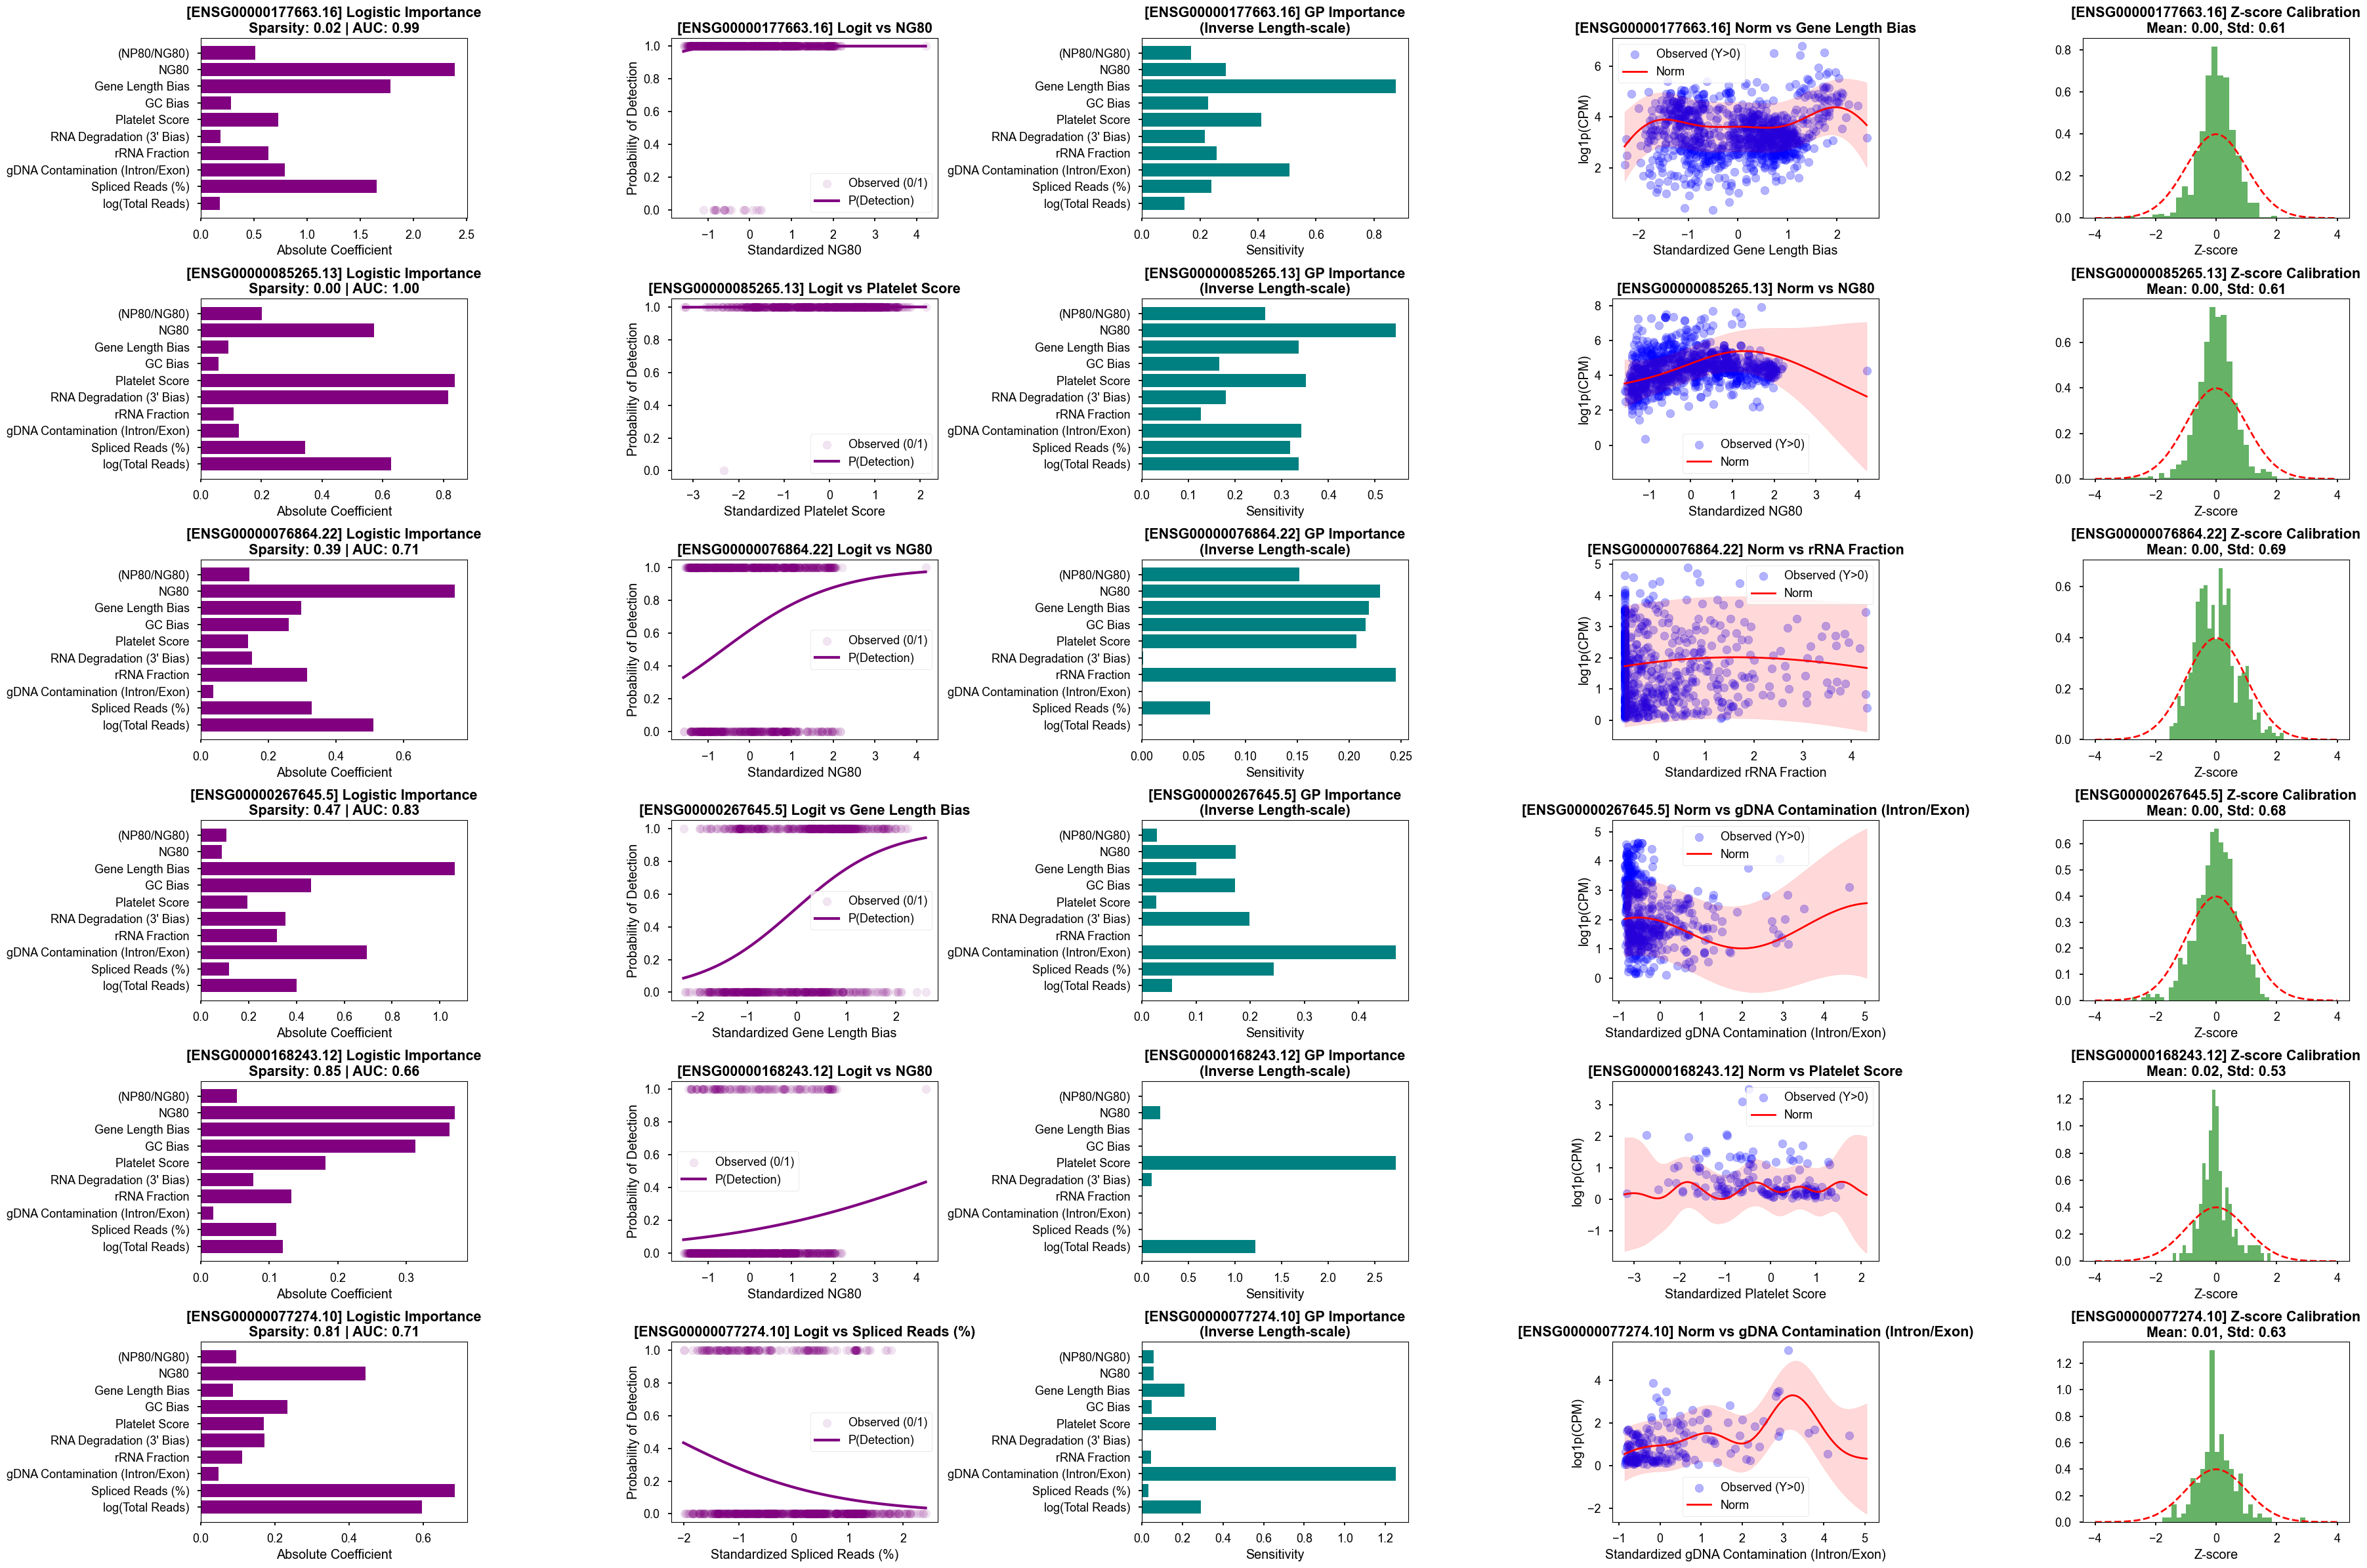

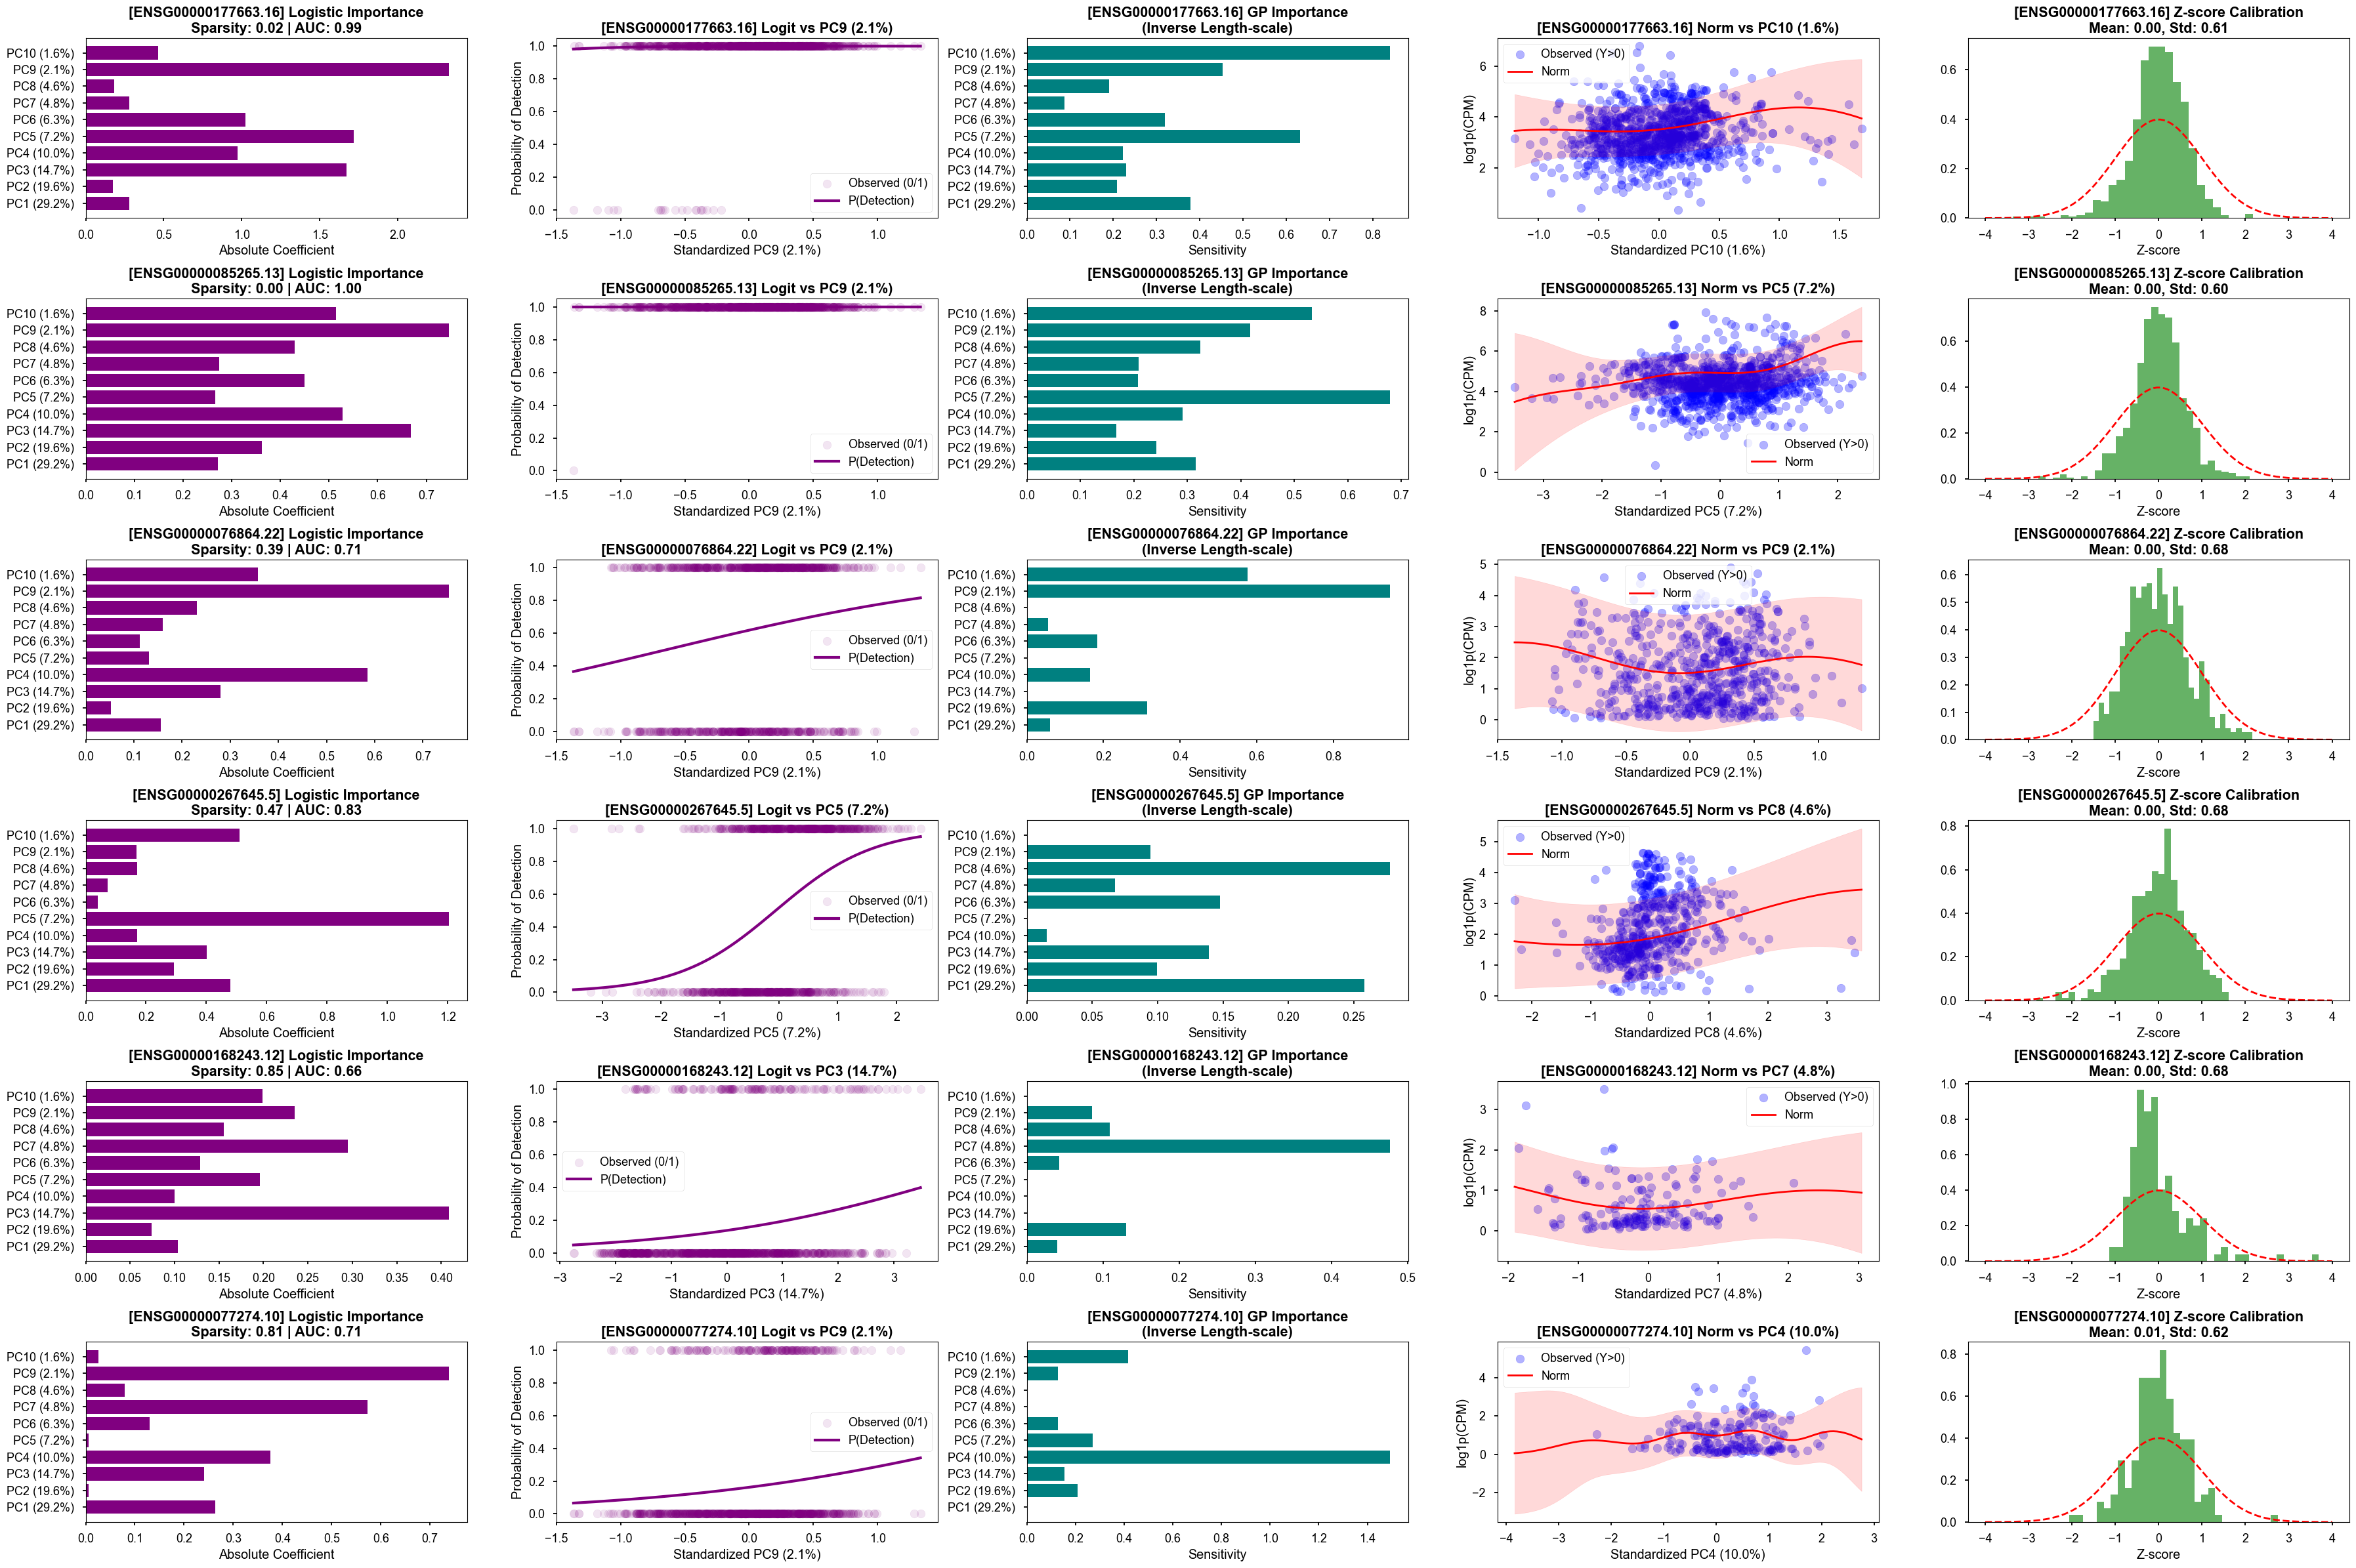

In [20]:
def plot_comprehensive_hurdle_results_v2(results, bias_columns):
    valid_results = [res for res in results if res["Status"] == "Success"]
    n_genes = len(valid_results)
    if n_genes == 0:
        return

    fig, axes = plt.subplots(nrows=n_genes, ncols=5, figsize=(36, 4 * n_genes))
    if n_genes == 1:
        axes = [axes] 

    for i, res in enumerate(valid_results):
        ax_row = axes[i]
        gene = res["Gene"]
        # --- [1] Logistic Importance ---
        ax_row[0].barh(bias_columns, np.abs(res["Logit_Coefs"]), color='purple')
        ax_row[0].set_title(f"[{gene}] Logistic Importance\nSparsity: {res['Sparsity']:.2f} | AUC: {res['AUC']:.2f}", fontweight='bold')
        ax_row[0].set_xlabel("Absolute Coefficient")
        # --- [2] Logistic 1D Projection (요청하신 S자 곡선) ---
        l_feat = res["Logit_Top_Feat"]
        # 타겟 값 산점도 (0 또는 1)
        ax_row[1].scatter(res["X_logit_obs"], res["Y_binary_obs"], color='purple', alpha=0.1, label='Observed (0/1)')
        # 발현 확률 곡선
        ax_row[1].plot(res["X_logit_range"], res["Prob_curve"], color='purple', lw=3, label='P(Detection)')
        ax_row[1].set_title(f"[{gene}] Logit vs {l_feat}", fontweight='bold')
        ax_row[1].set_xlabel(f"Standardized {l_feat}")
        ax_row[1].set_ylabel("Probability of Detection")
        ax_row[1].legend()
        # --- [3] GP Feature Importance ---
        gp_importance = 1.0 / res["GP_L_Scales"]
        ax_row[2].barh(bias_columns, gp_importance, color='teal')
        ax_row[2].set_title(f"[{gene}] GP Importance\n(Inverse Length-scale)", fontweight='bold')
        ax_row[2].set_xlabel("Sensitivity")
        # --- [4] GP 1D Normative Projection ---
        g_feat = res["GP_Top_Feat"]
        ax_row[3].scatter(res["X_gp_obs"], res["Y_cont_obs"], color='blue', alpha=0.3, label='Observed (Y>0)')
        ax_row[3].plot(res["X_gp_range"], res["Mu_p"], color='red', lw=2, label='Norm')
        ax_row[3].fill_between(res["X_gp_range"], res["Mu_p"] - 1.96*res["Std_p"], res["Mu_p"] + 1.96*res["Std_p"], color='red', alpha=0.15)
        ax_row[3].set_title(f"[{gene}] Norm vs {g_feat}", fontweight='bold')
        ax_row[3].set_xlabel(f"Standardized {g_feat}")
        ax_row[3].set_ylabel("log1p(CPM)")
        ax_row[3].legend()
        # --- [5] Z-score Calibration Histogram ---
        z_scores = res["Z_scores"]
        ax_row[4].hist(z_scores, bins=30, density=True, alpha=0.6, color='green')
        x_axis = np.linspace(-4, 4, 100)
        ax_row[4].plot(x_axis, norm.pdf(x_axis, 0, 1), 'r--', lw=2)
        ax_row[4].set_title(f"[{gene}] Z-score Calibration\nMean: {np.mean(z_scores):.2f}, Std: {np.std(z_scores):.2f}", fontweight='bold')
        ax_row[4].set_xlabel("Z-score")

    plt.tight_layout()
    plt.show()

plot_comprehensive_hurdle_results_v2(results, bias_columns)
plot_comprehensive_hurdle_results_v2(results_pca, pc_columns)

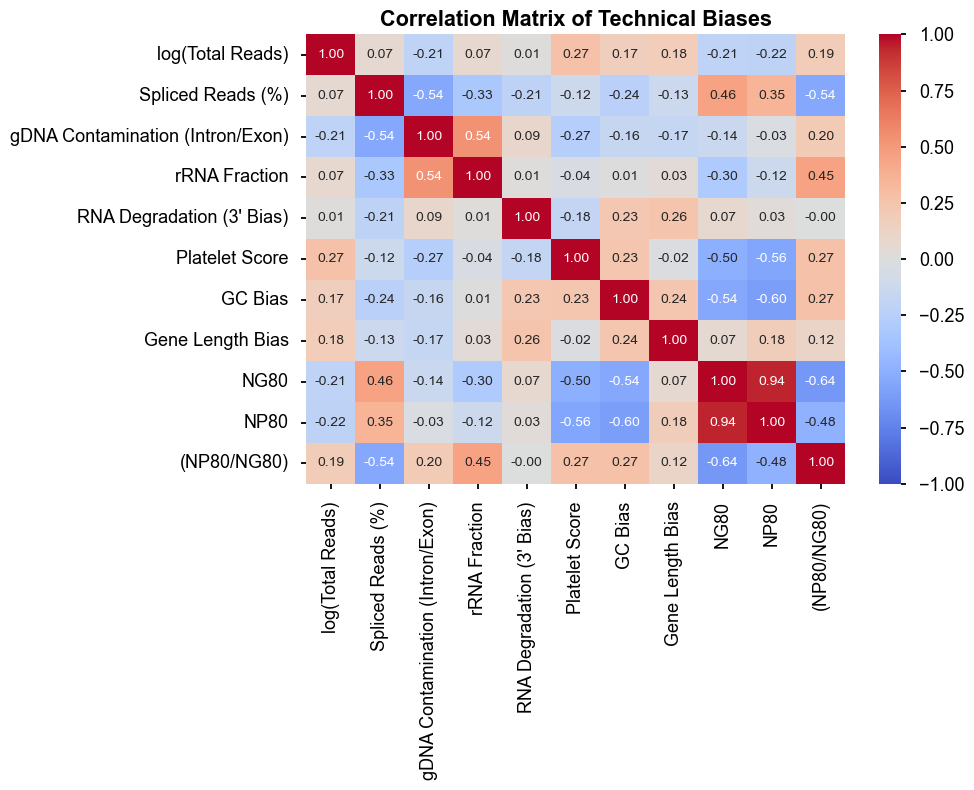

=== Variance Inflation Factor (VIF) ===


,Feature,VIF
9,NP80,23.625051
8,NG80,23.372319
2,gDNA Contamination (Intron/Exon),2.838674
10,(NP80/NG80),2.690241
1,Spliced Reads (%),2.650139
6,GC Bias,2.352371
3,rRNA Fraction,2.139830
5,Platelet Score,1.951817
7,Gene Length Bias,1.891523
4,RNA Degradation (3' Bias),1.383263


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
covariates = [
        'log(Total Reads)', 'Spliced Reads (%)', 'gDNA Contamination (Intron/Exon)',
        'rRNA Fraction', "RNA Degradation (3' Bias)", 'Platelet Score',
        'GC Bias', 'Gene Length Bias', 'NG80', 'NP80', '(NP80/NG80)'
    ]

X_df = adata.obs[covariates].dropna()
plt.figure(figsize=(10, 8))
corr_matrix = X_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Technical Biases", fontweight='bold')
plt.tight_layout()
plt.show()

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_df), columns=X_df.columns)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_scaled.columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled.values, i) for i in range(X_scaled.shape[1])]

print("=== Variance Inflation Factor (VIF) ===")
vif_data.sort_values(by="VIF", ascending=False)

### 